# **Seasonal Agriculture Performance Analysis**

## **Introduction**

This project analyzes agricultural activities across different seasons to understand how environmental conditions, resource usage, crop production, and economic performance vary throughout the year.

The analysis focuses on identifying seasonal patterns, trends, relationships, and differences that can support better agricultural planning and decision-making.

## **Problem Statement**

Agricultural performance varies due to seasonal changes in environmental conditions, farming practices, resource availability, and market conditions.

This project aims to analyze seasonal agricultural data and identify meaningful patterns, trends, relationships, and differences in agricultural performance.

## **Objectives**

• Explore and understand the dataset
• Clean and prepare data
• Analyze seasonal agricultural performance
• Identify seasonal trends and patterns
• Investigate relationships between environmental factors and outcomes
• Compare agricultural activities across seasons
• Develop insights and recommendations

In [99]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
#Load the Dataset

data = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

**Dataset Overview**

In [101]:
# Display Top 5 Records

data.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [102]:
# Display Bottom 5 records

data.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [103]:
# Display the Dimension of data structure

print("Number of rows:",data.shape[0])
print("Number of columns:",data.shape[1])

Number of rows: 4000
Number of columns: 28


In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [105]:
# It display Statistical summary

data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


**Data Quality Check**

In [106]:
# Check the Missing value

data.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [107]:
# check Duplicate Records

data.duplicated().sum()

np.int64(0)

In [108]:
# Handle missing values by replacing them with the mean of their group
data['Rainfall_mm'] = data['Rainfall_mm'].fillna(data.groupby('Season')['Rainfall_mm'].transform('mean'))
data['Soil_Moisture_pct'] = data['Soil_Moisture_pct'].fillna(data.groupby('Season')['Soil_Moisture_pct'].transform('mean'))
data['Yield_Tonnes_Ha'] = data['Yield_Tonnes_Ha'].fillna(data.groupby('Crop')['Yield_Tonnes_Ha'].transform('mean'))


In [109]:
# Remove duplicates

data = data.drop_duplicates()

In [110]:
# Data Types

data.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


**Outlier Detection**

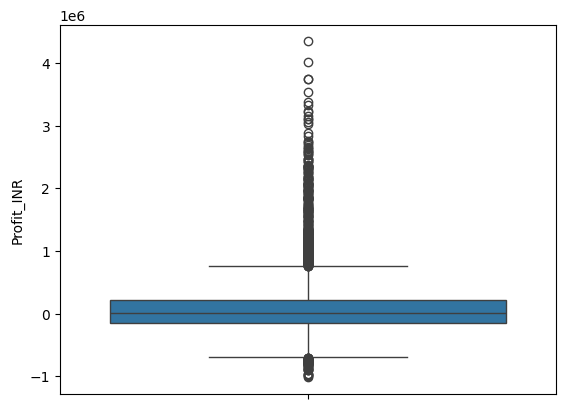

In [111]:
# Outlier Detection for Profit_INR

sns.boxplot(data['Profit_INR'])
plt.show()

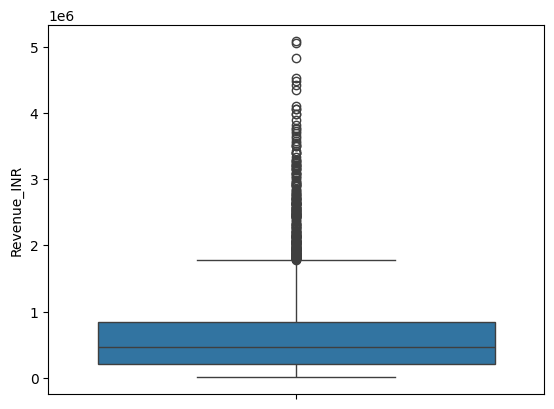

In [112]:
# Outlier Detection for Revenue_INR

sns.boxplot(data['Revenue_INR'])
plt.show()

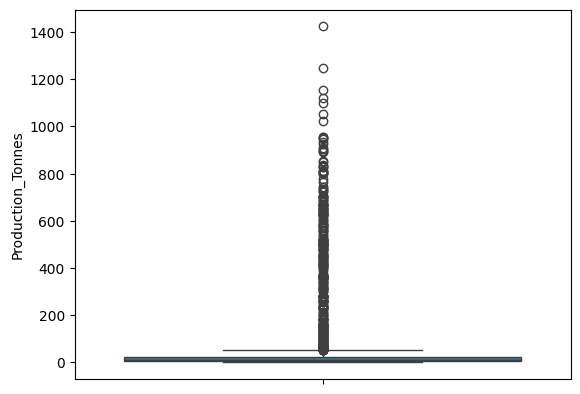

In [113]:
# Outlier Detection for Production_Tonnes

sns.boxplot(data['Production_Tonnes'])
plt.show()

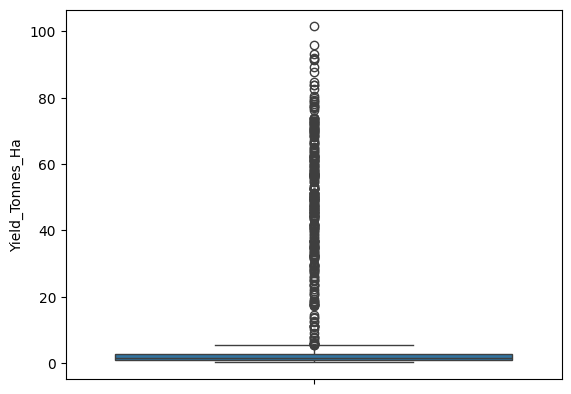

In [114]:
# Outlier Detection for Yield_Tonnes_Ha

sns.boxplot(data['Yield_Tonnes_Ha'])
plt.show()

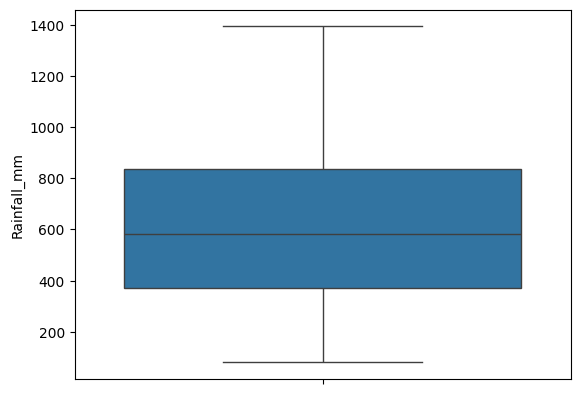

In [115]:
# Outlier Detection for Rainfall_mm

sns.boxplot(data['Rainfall_mm'])
plt.show()

**Data Understanding**

In [116]:
# Total Farms

data['Farm_ID'].nunique()

4000

In [117]:
# Total States

data['State'].nunique()

8

In [118]:
# Total Crops

data['Crop'].nunique()

8

In [119]:
# Total Districts

data['District'].unique()

array(['Rajkot', 'Nalgonda', 'Warangal', 'Indore', 'Ludhiana', 'Raichur',
       'Guntur', 'Krishna', 'Nashik', 'Erode'], dtype=object)

In [120]:
# Season Distribution

data['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


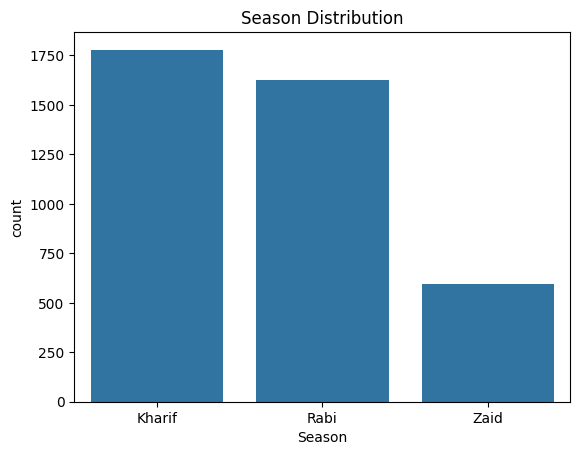

In [121]:
sns.countplot(data=data,x='Season')
plt.title("Season Distribution")
plt.show()

**Feature Engineering**

In [122]:
# Profit Margin %

data['Profit_Margin_%'] = (
    data['Profit_INR'] /
    data['Revenue_INR']
)*100

In [123]:
data[['Revenue_INR',
      'Profit_INR',
      'Profit_Margin_%']].head()

,Revenue_INR,Profit_INR,Profit_Margin_%
0,30810,-11852,-38.468030
1,40401,-451950,-1118.660429
2,190466,-124744,-65.494104
3,200740,-95704,-47.675600
4,193607,-144352,-74.559288


In [124]:
# Clip extreme percentage values so they don't skew your seasonal bar charts
data['Profit_Margin_%'] = data['Profit_Margin_%'].clip(lower=-100, upper=100)

**Seasonal Performance Analysis**

In [125]:
# Average Yield by Season

yield_Season = data.groupby('Season')['Yield_Tonnes_Ha'].mean()
yield_Season

,Yield_Tonnes_Ha
Season,
Kharif,5.629360
Rabi,5.096753
Zaid,4.640037


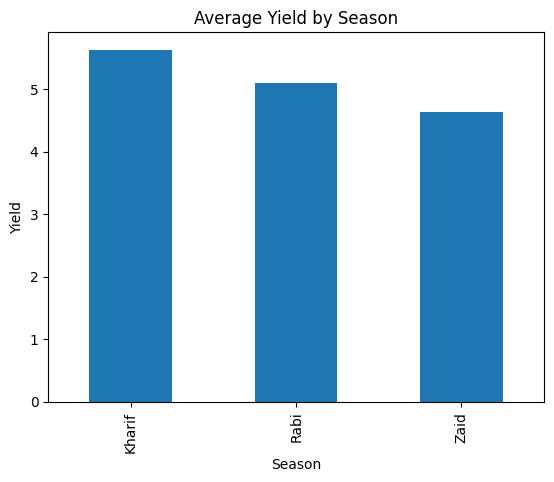

In [126]:
yield_Season.plot(kind='bar')
plt.title("Average Yield by Season")
plt.ylabel("Yield")
plt.show()

In [127]:
# Average Production by Season

prod_season = data.groupby('Season')['Production_Tonnes'].mean()
prod_season

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


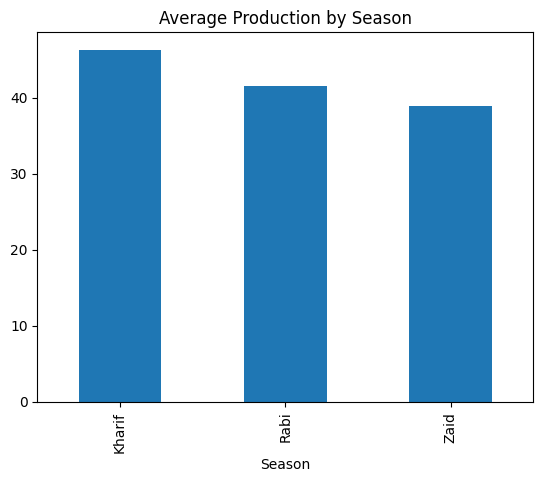

In [128]:
prod_season.plot(kind='bar')
plt.title("Average Production by Season")
plt.show()

In [129]:
# Revenue by Season

rev_season = data.groupby('Season')['Revenue_INR'].mean()
rev_season

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


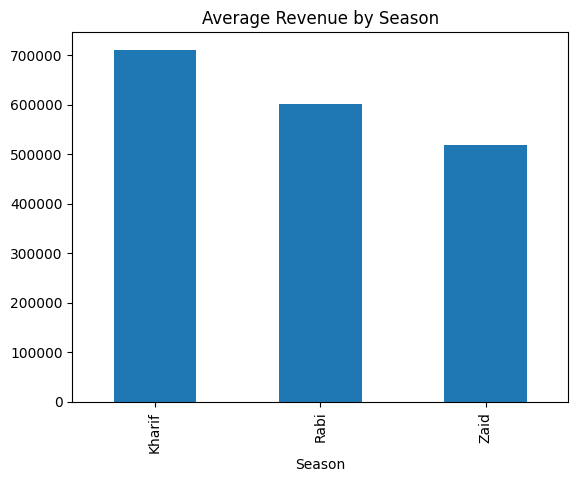

In [130]:
rev_season.plot(kind='bar')
plt.title("Average Revenue by Season")
plt.show()

In [131]:
# Profit by Season

profit_season = data.groupby('Season')['Profit_INR'].mean()
profit_season

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


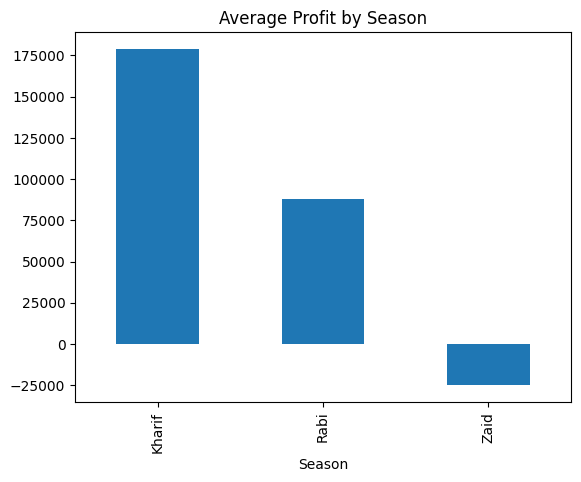

In [132]:
profit_season.plot(kind='bar')
plt.title("Average Profit by Season")
plt.show()

Average Metrics by Season:


,Season,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR
0,Kharif,5.629360,46.311192,531804.408094,710719.055649,178914.647555
1,Rabi,5.096753,41.486712,513836.578365,601526.048556,87689.470191
2,Zaid,4.640037,38.886111,543976.728956,519171.904040,-24804.824916


/tmp/ipykernel_2644/782108211.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Season', y='Profit_INR', ax=axes[0], palette='Set2')
/tmp/ipykernel_2644/782108211.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Season', y='Yield_Tonnes_Ha', ax=axes[1], palette='Set2')


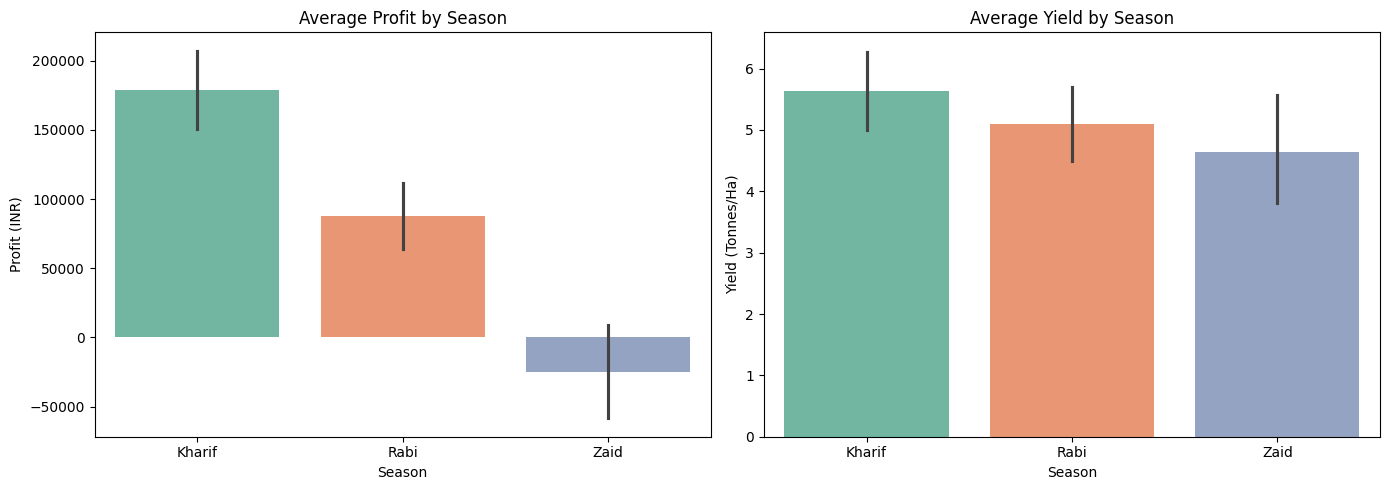

In [170]:
# Aggregate key metrics by Season
seasonal_summary = data.groupby('Season')[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean().reset_index()
print("Average Metrics by Season:")
display(seasonal_summary)

# Visualize Profit and Yield across Seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=data, x='Season', y='Profit_INR', ax=axes[0], palette='Set2')
axes[0].set_title('Average Profit by Season')
axes[0].set_ylabel('Profit (INR)')

sns.barplot(data=data, x='Season', y='Yield_Tonnes_Ha', ax=axes[1], palette='Set2')
axes[1].set_title('Average Yield by Season')
axes[1].set_ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [133]:
# Profit Margin by Season

data.groupby('Season')['Profit_Margin_%'].mean()

,Profit_Margin_%
Season,
Kharif,-3.512439
Rabi,-13.222302
Zaid,-28.720644


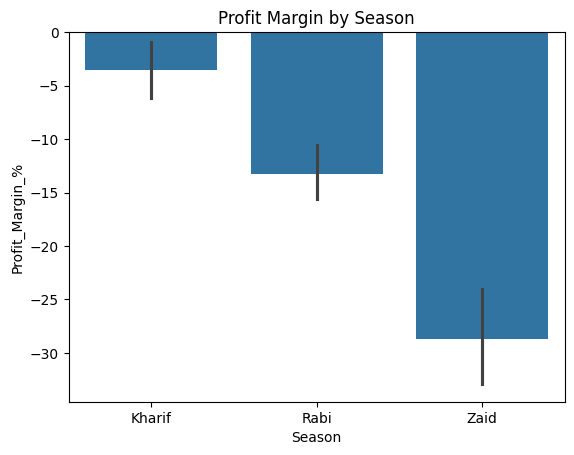

In [134]:
sns.barplot(
    data=data,
    x='Season',
    y='Profit_Margin_%'
)

plt.title("Profit Margin by Season")
plt.show()

**Environmental Analysis**

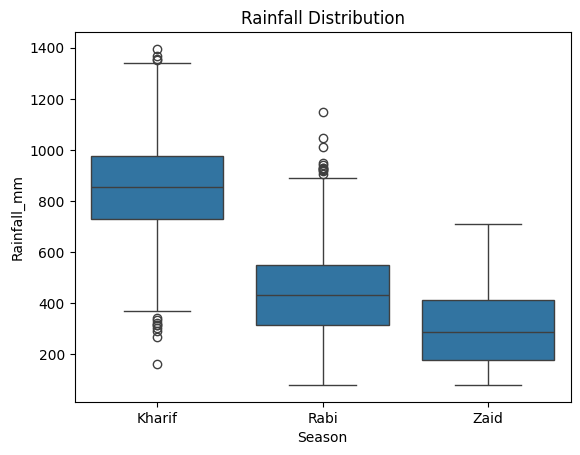

In [135]:
# Rainfall by Season

sns.boxplot(
    data=data,
    x='Season',
    y='Rainfall_mm'
)

plt.title("Rainfall Distribution")
plt.show()

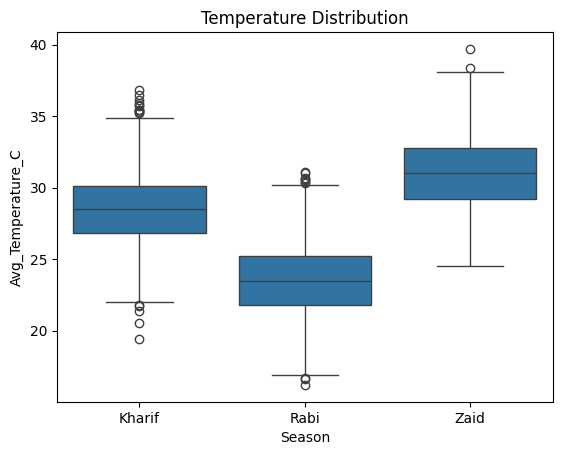

In [136]:
# Temperature by Season

sns.boxplot(
    data=data,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title("Temperature Distribution")
plt.show()

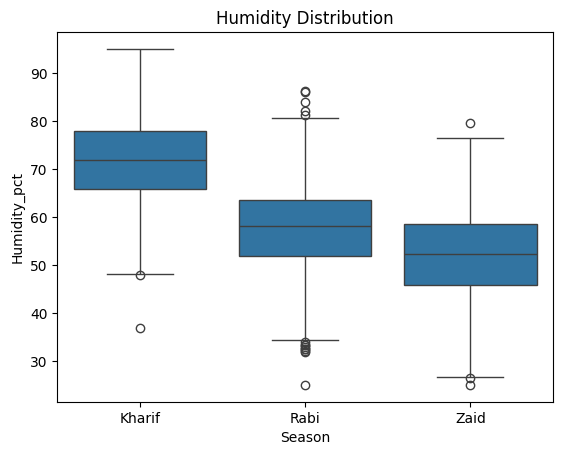

In [137]:
# Humidity by Season

sns.boxplot(
    data=data,
    x='Season',
    y='Humidity_pct'
)

plt.title("Humidity Distribution")
plt.show()

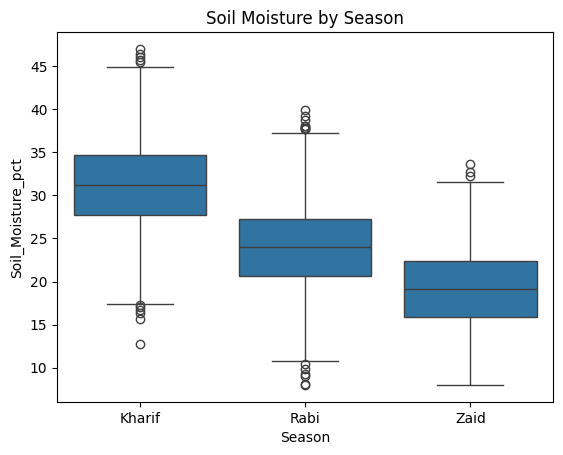

In [138]:
# Soil Moisture by Season

sns.boxplot(
    data=data,
    x='Season',
    y='Soil_Moisture_pct'
)

plt.title("Soil Moisture by Season")
plt.show()

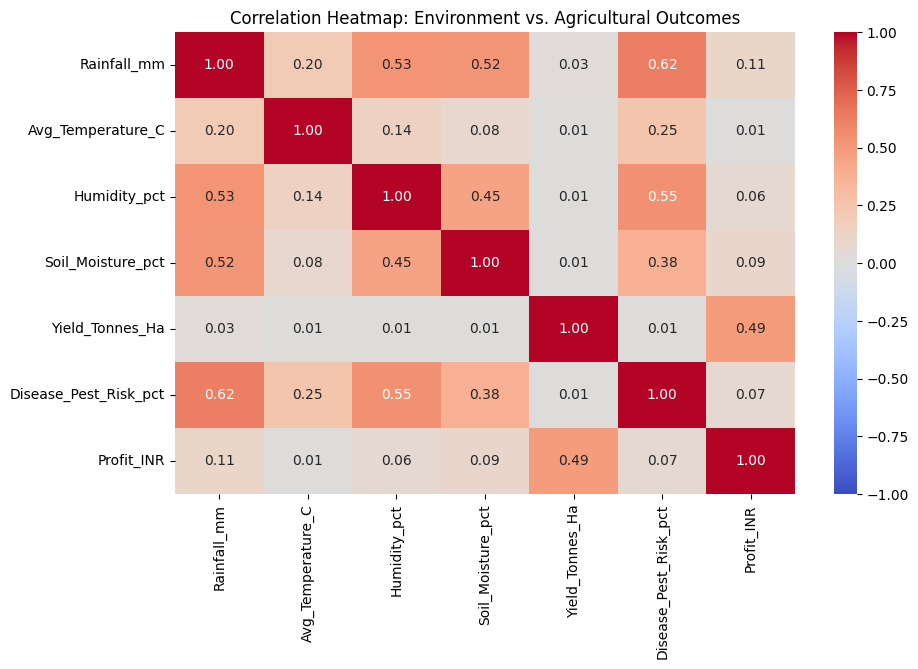

In [171]:
# Correlation Matrix for Environmental & Outcome Variables
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha', 'Disease_Pest_Risk_pct', 'Profit_INR']

plt.figure(figsize=(10, 6))
sns.heatmap(data[env_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Environment vs. Agricultural Outcomes')
plt.show()

**Resource Usage Analysis**

In [139]:
# Water Usage

data.groupby('Season')['Water_Used_m3'].mean()

,Water_Used_m3
Season,
Kharif,6102.201237
Rabi,5846.987093
Zaid,6419.893939


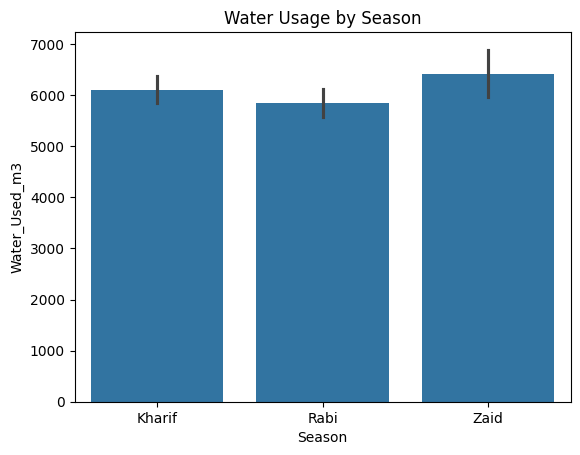

In [140]:
sns.barplot(
    data=data,
    x='Season',
    y='Water_Used_m3'
)

plt.title("Water Usage by Season")
plt.show()

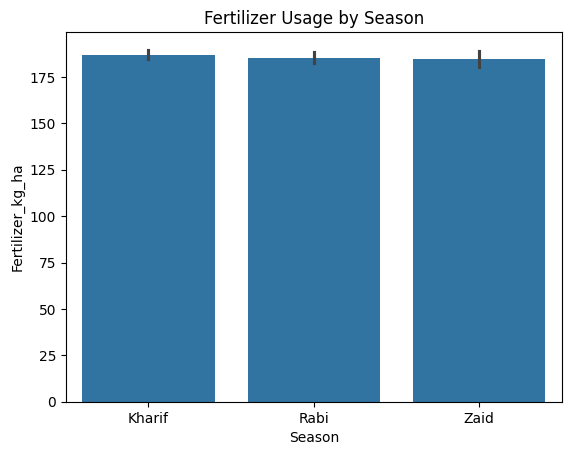

In [141]:
# Fertilizer Usage

sns.barplot(
    data=data,
    x='Season',
    y='Fertilizer_kg_ha'
)

plt.title("Fertilizer Usage by Season")
plt.show()

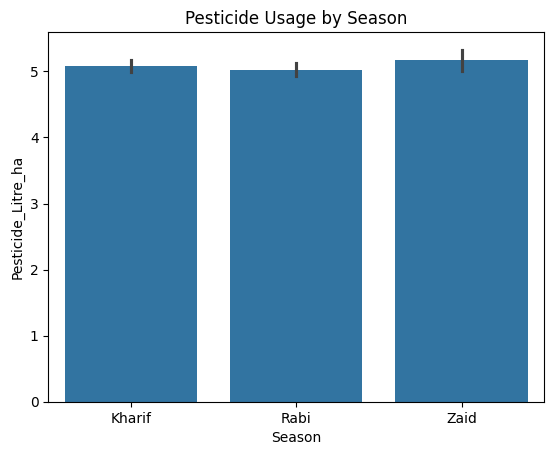

In [142]:
# Pesticide Usage

sns.barplot(
    data=data,
    x='Season',
    y='Pesticide_Litre_ha'
)

plt.title("Pesticide Usage by Season")
plt.show()

/tmp/ipykernel_2644/1793135140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', palette='Pastel1')


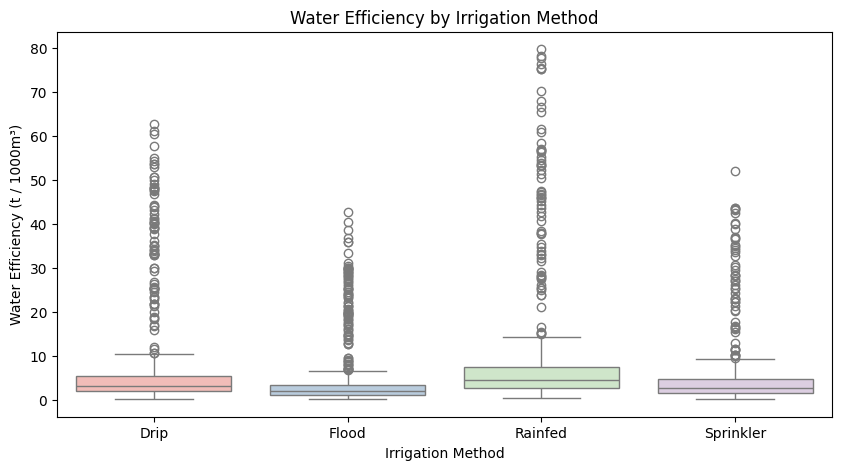

In [172]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', palette='Pastel1')
plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t / 1000m³)')
plt.show()

**Disease Risk Analysis**

In [143]:
# Disease Risk Analysis

data.groupby('Season')['Disease_Pest_Risk_pct'].mean()

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


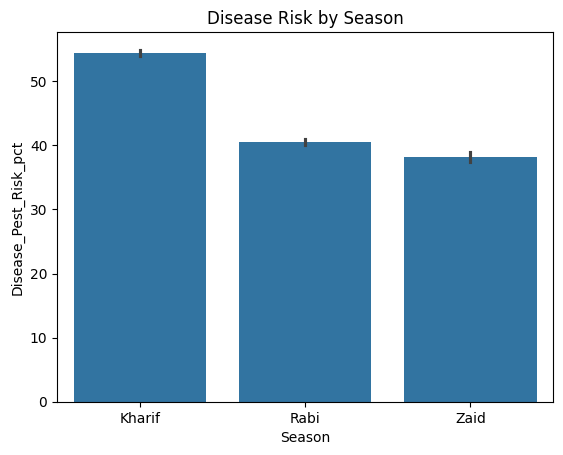

In [144]:
sns.barplot(
    data=data,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title("Disease Risk by Season")
plt.show()

**Crop Performance Analysis**

In [145]:
# Top 10 Crops by Profit

crop_profit = (
    data.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

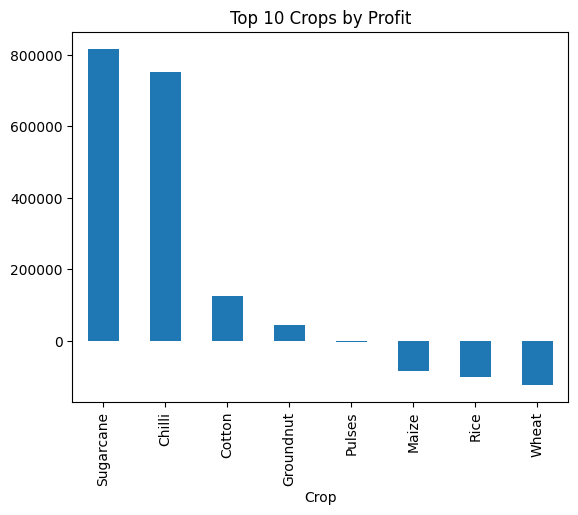

In [146]:
crop_profit.head(10).plot(kind='bar')
plt.title("Top 10 Crops by Profit")
plt.show()

In [147]:
# Crop vs Season

crop_season = pd.pivot_table(
    data,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.730380,1.462581,1.189073
Cotton,1.372120,1.193241,0.954628
Groundnut,1.482787,1.223625,1.037778
Maize,2.966410,2.616229,2.302585
Pulses,1.036063,0.872104,0.656423
Rice,2.705058,2.335610,1.900490
Sugarcane,53.459120,43.986880,38.423922
Wheat,2.254929,2.059026,1.748588


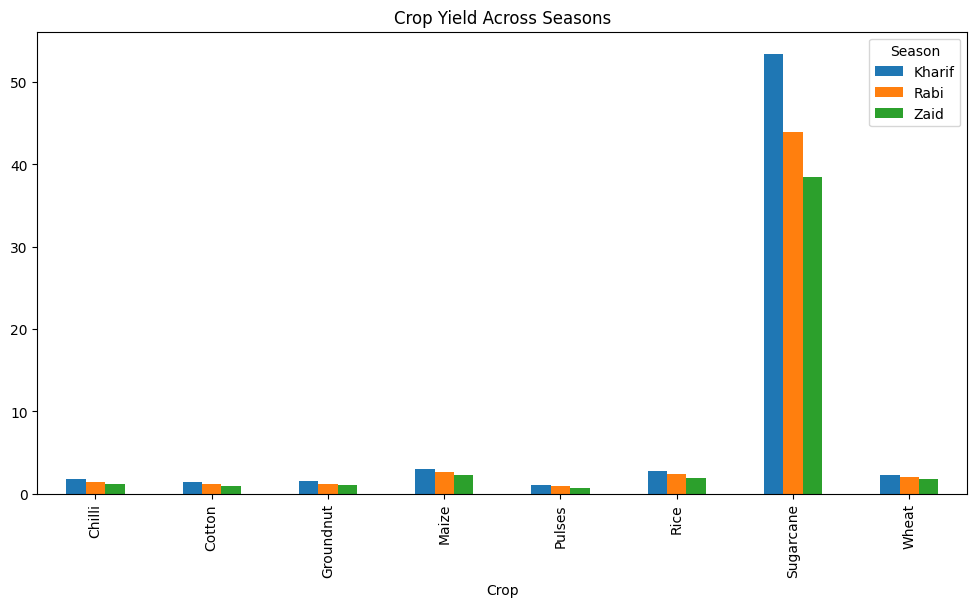

In [148]:
crop_season.plot(kind='bar', figsize=(12,6))
plt.title("Crop Yield Across Seasons")
plt.show()

**State Analysis**

In [149]:
# Top States by Profit

state_profit = (
    data.groupby('State')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

state_profit.head(10)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


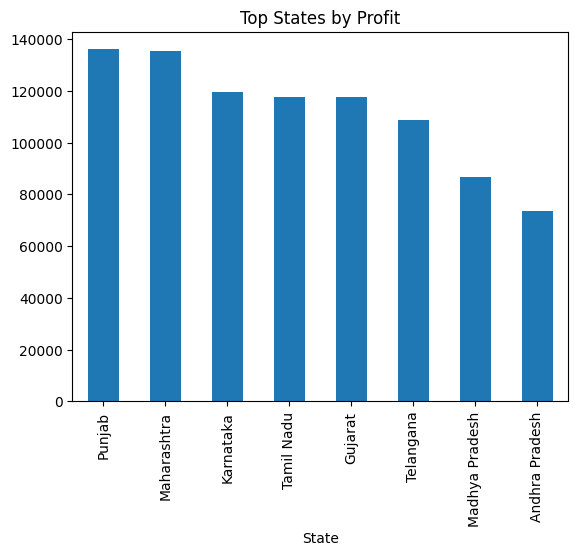

In [150]:
state_profit.head(10).plot(kind='bar')
plt.title("Top States by Profit")
plt.show()

In [151]:
# State-wise Seasonal Performance

state_season = pd.pivot_table(
    data,
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

state_season.head()

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169315.520833,26315.710784,-84084.870588
Gujarat,217051.330317,82846.195000,-106929.611940
Karnataka,201226.205742,70952.611650,23310.905405
Madhya Pradesh,134242.398230,61576.264423,209.698413
Maharashtra,168801.049550,159581.504587,-40597.597222


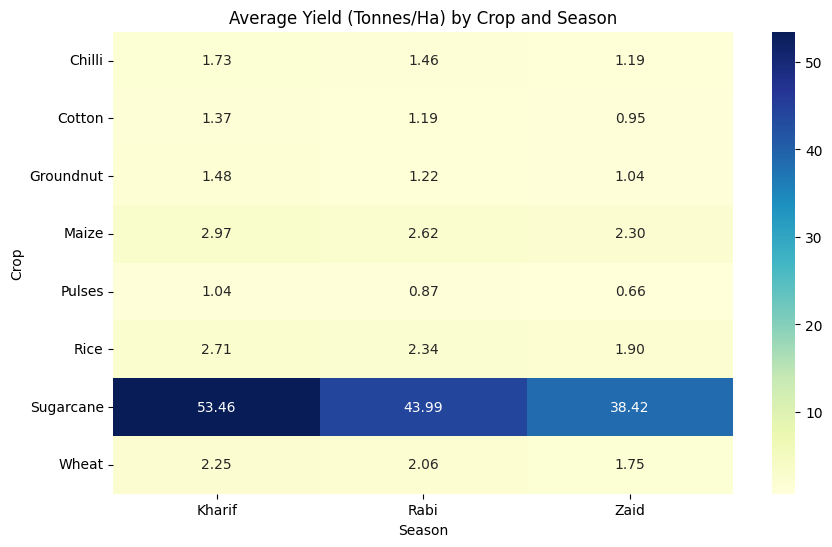

In [173]:
# Crop yield breakdown by Season
crop_seasonal_yield = data.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(crop_seasonal_yield, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Average Yield (Tonnes/Ha) by Crop and Season')
plt.ylabel('Crop')
plt.xlabel('Season')
plt.show()

**Relationship Analysis**

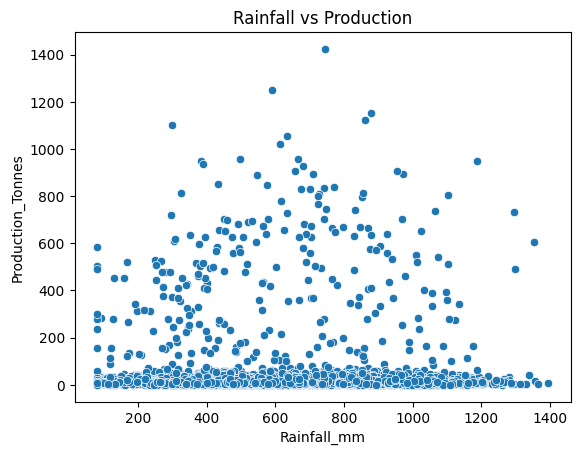

In [152]:
# Rainfall vs Production

sns.scatterplot(
    data=data,
    x='Rainfall_mm',
    y='Production_Tonnes'
)

plt.title("Rainfall vs Production")
plt.show()

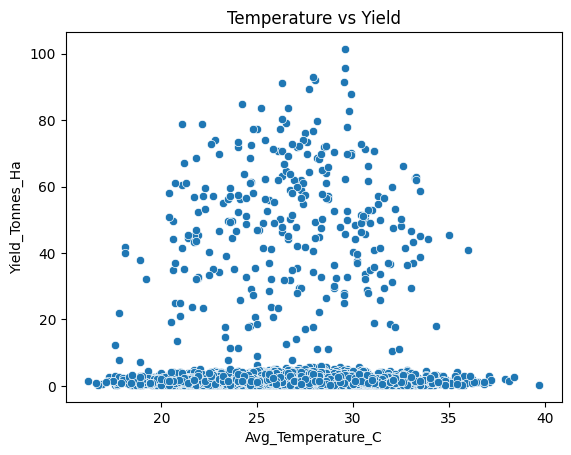

In [153]:
# Temperature vs Yield

sns.scatterplot(
    data=data,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha'
)

plt.title("Temperature vs Yield")
plt.show()

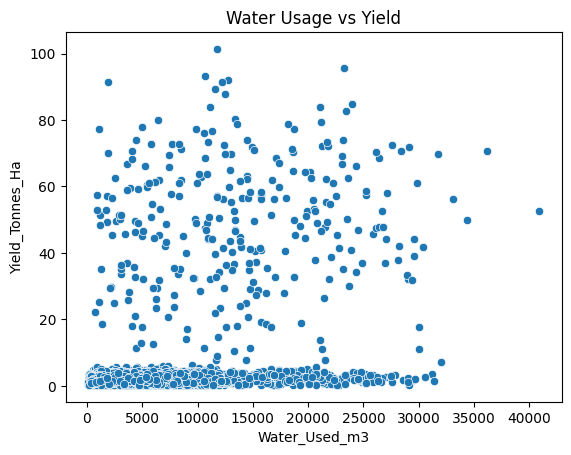

In [154]:
# Water Usage vs Yield

sns.scatterplot(
    data=data,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha'
)

plt.title("Water Usage vs Yield")
plt.show()

**Correlation Heatmap**

In [155]:
# Correlation Heatmap

numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

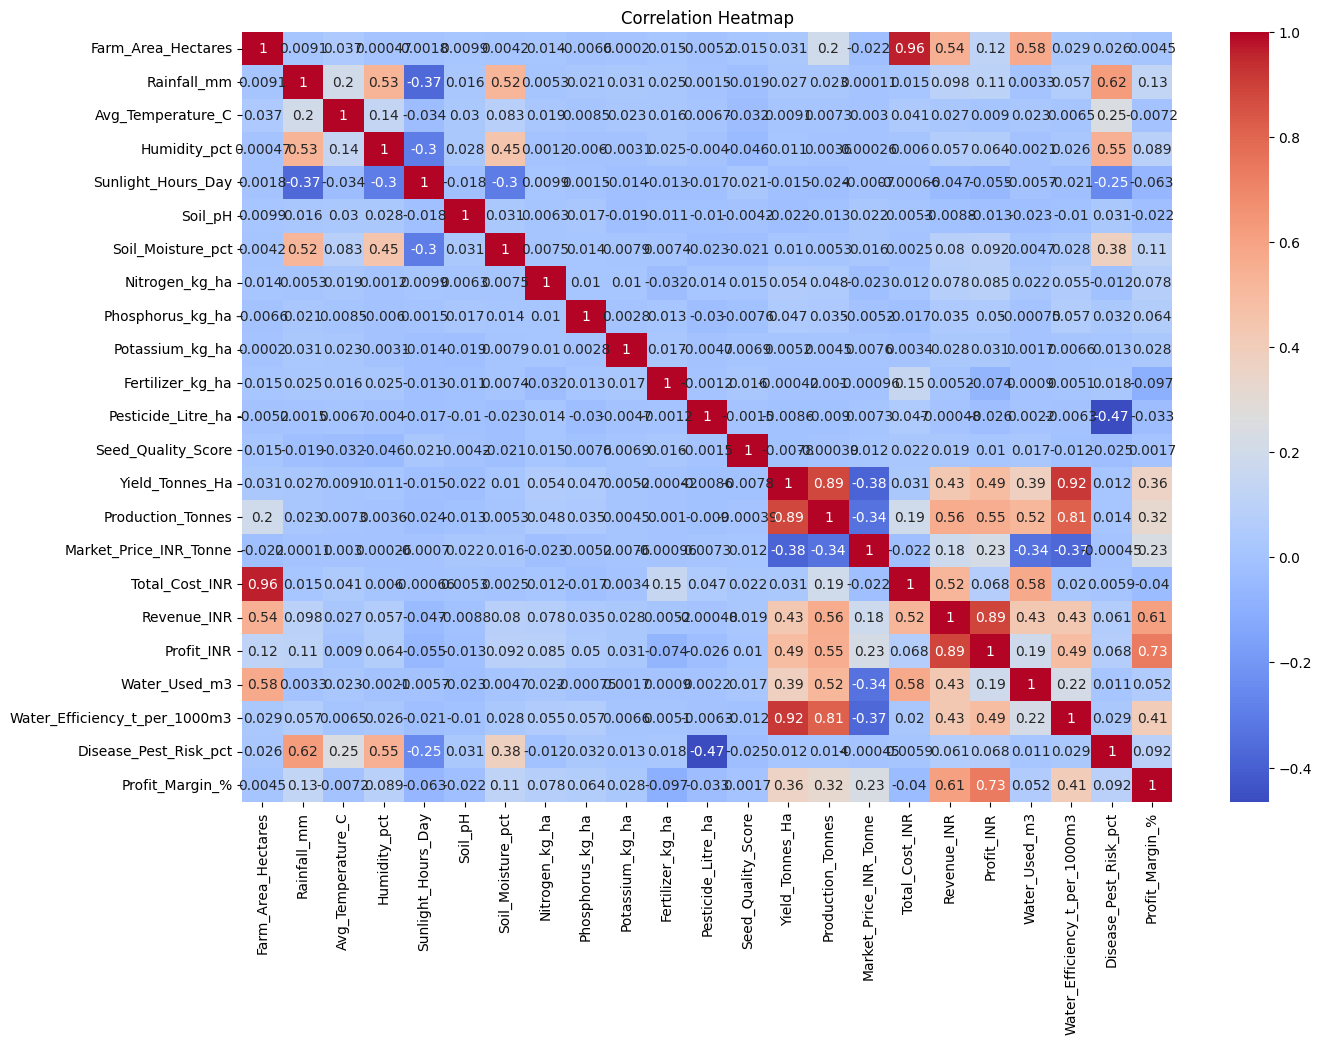

In [156]:
plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [157]:
from scipy.stats import f_oneway

In [158]:
# Statistical Analysis (ANOVA)

kharif = data[data['Season']=='Kharif']['Profit_INR']

rabi = data[data['Season']=='Rabi']['Profit_INR']

zaid = data[data['Season']=='Zaid']['Profit_INR']

f_stat, p_value = f_oneway(
    kharif,
    rabi,
    zaid
)

print("F Statistic:",f_stat)
print("P Value:",p_value)

F Statistic: 34.29175033935195
P Value: 1.7124156677360182e-15


In [159]:
if p_value < 0.05:
    print("Significant difference exists between seasons")
else:
    print("No significant difference found")

Significant difference exists between seasons


**KPI Summary Table**

In [160]:
# KPI Summary Table

summary = data.groupby('Season').agg({
    'Yield_Tonnes_Ha':'mean',
    'Production_Tonnes':'mean',
    'Revenue_INR':'mean',
    'Profit_INR':'mean',
    'Rainfall_mm':'mean',
    'Water_Used_m3':'mean'
})

summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Rainfall_mm,Water_Used_m3
Season,,,,,,
Kharif,5.629360,46.311192,710719.055649,178914.647555,852.084205,6102.201237
Rabi,5.096753,41.486712,601526.048556,87689.470191,436.000124,5846.987093
Zaid,4.640037,38.886111,519171.904040,-24804.824916,299.421784,6419.893939


**Economic Performance Analysis**

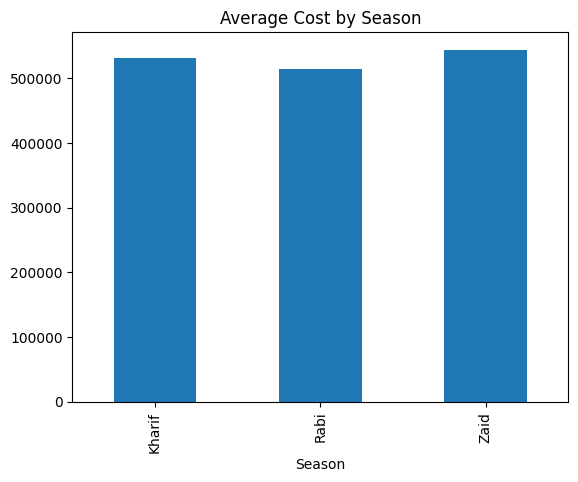

In [161]:
# How do economic outcomes vary across seasons?

cost_season = data.groupby('Season')['Total_Cost_INR'].mean()

cost_season.plot(kind='bar')
plt.title("Average Cost by Season")
plt.show()

**Regional Consistency Analysis**

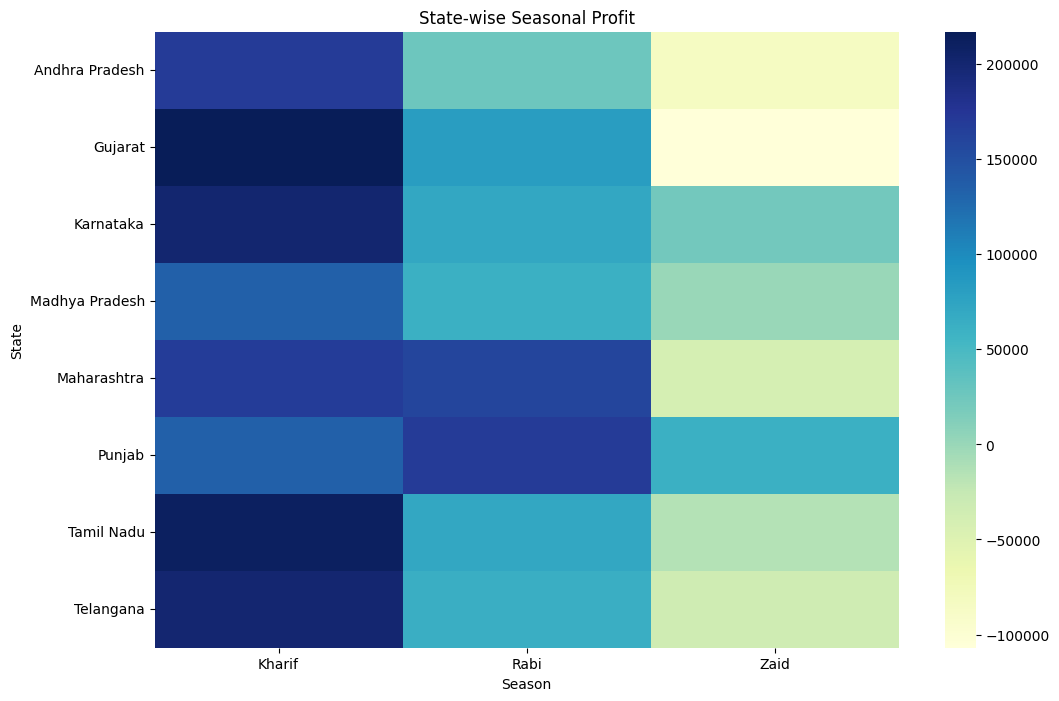

In [162]:
# Are patterns consistent across different regions?

state_season_profit = pd.pivot_table(
    data,
    values='Profit_INR',
    index='State',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(state_season_profit,cmap='YlGnBu')
plt.title("State-wise Seasonal Profit")
plt.show()

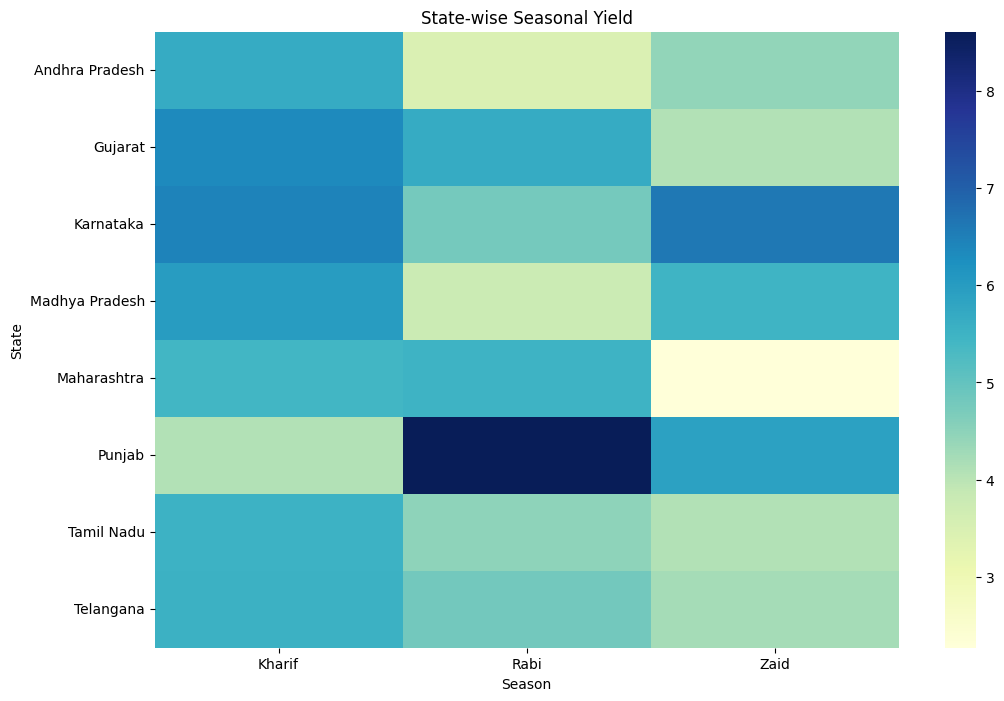

In [163]:
state_season_yield = pd.pivot_table(
    data,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(state_season_yield,cmap='YlGnBu')
plt.title("State-wise Seasonal Yield")
plt.show()

**Crop Seasonal Performance**

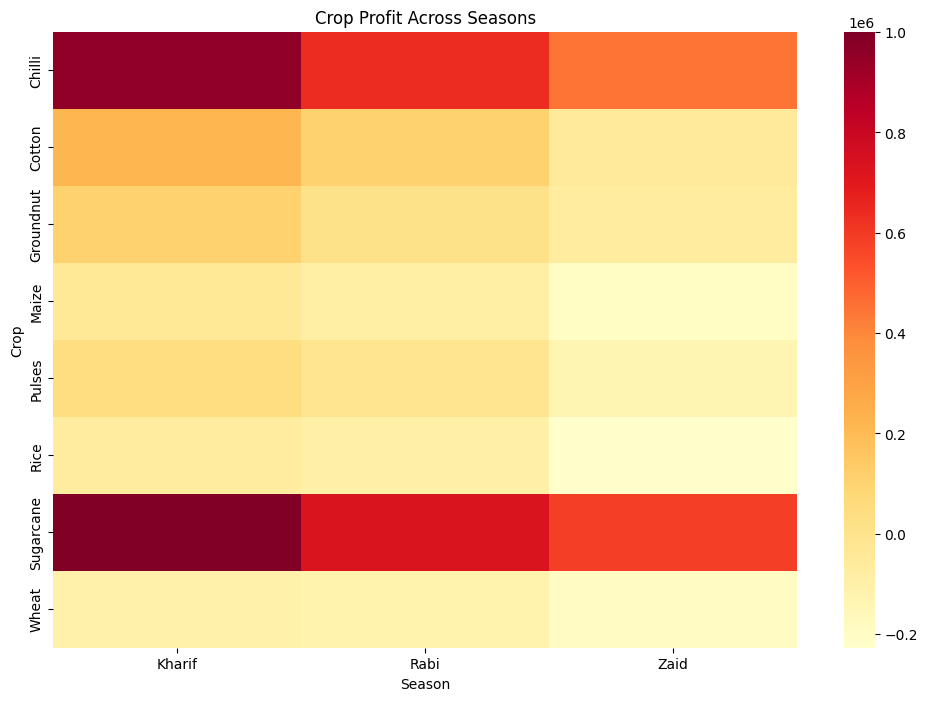

In [164]:
crop_profit_season = pd.pivot_table(
    data,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))
sns.heatmap(crop_profit_season,cmap='YlOrRd')
plt.title("Crop Profit Across Seasons")
plt.show()

**Unusual Pattern Analysis**

In [165]:
# Highest Profit Farms

data.nlargest(10,'Profit_INR')

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_%
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,12.74,723.4,26.2,69.0,7.1,...,3.90,49.69,101780,712027,5057448,4345421,10398,4.779,52.3,85.921220
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,14.45,806.5,28.9,68.9,8.6,...,2.92,42.19,120429,1059050,5080900,4021850,10980,3.842,58.0,79.156252
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,13.96,879.1,29.8,76.1,5.6,...,82.68,1154.21,3886,745161,4485260,3740099,23472,49.174,64.6,83.386448
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,13.04,921.0,28.4,77.6,6.5,...,3.01,39.25,115222,784135,4522464,3738329,7074,5.548,47.4,82.661332
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,14.86,566.3,27.6,69.4,6.4,...,3.09,45.92,105082,1283161,4825365,3542204,12869,3.568,40.2,73.408001
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,589.1,24.2,54.5,8.0,...,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190,43.8,77.657563
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,745.9,29.6,74.1,6.4,...,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162,42.7,75.208583
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,14.16,860.4,26.5,74.0,5.0,...,79.25,1122.18,3661,875331,4108301,3232970,21133,53.101,41.8,78.693601
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,13.68,717.2,29.3,66.4,7.8,...,3.02,41.31,98175,844264,4055609,3211345,7219,5.722,49.6,79.182806
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,13.95,866.6,27.4,49.1,8.5,...,2.53,35.29,112997,828217,3987664,3159447,8108,4.352,56.3,79.230522


In [166]:
# Lowest Profit Farms

data.nsmallest(10,'Profit_INR')

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_%
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,14.64,170.8,22.1,62.7,7.6,...,0.300000,4.39,63813,1299362,280139,-1019223,7779,0.564,29.3,-100.0
2210,SF12211,Andhra Pradesh,Raichur,Wheat,Rabi,14.27,347.6,22.7,54.4,7.9,...,0.300000,4.28,23948,1097692,102497,-995195,6506,0.658,42.5,-100.0
3625,SF13626,Punjab,Krishna,Maize,Rabi,13.47,439.1,19.5,54.5,7.0,...,0.970000,13.07,17330,1207553,226503,-981050,9675,1.351,27.7,-100.0
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,14.72,812.4,29.3,72.9,7.1,...,1.010000,14.87,21578,1297725,320865,-976860,25877,0.575,40.8,-100.0
104,SF10105,Gujarat,Krishna,Wheat,Zaid,12.30,80.0,30.5,61.2,10.2,...,0.300000,3.69,26773,1063989,98792,-965197,9826,0.376,31.3,-100.0
3394,SF13395,Gujarat,Erode,Wheat,Kharif,13.41,634.3,25.2,77.8,7.5,...,0.300000,4.02,24787,1063040,99644,-963396,9139,0.440,44.8,-100.0
2730,SF12731,Madhya Pradesh,Ludhiana,Rice,Rabi,11.99,535.0,21.7,64.0,6.2,...,2.439413,3.60,24777,995279,89197,-906082,18723,0.192,35.4,-100.0
1311,SF11312,Punjab,Rajkot,Rice,Zaid,13.55,152.9,29.2,44.4,7.8,...,0.450000,6.10,26735,1065824,163084,-902740,15849,0.385,21.2,-100.0
585,SF10586,Telangana,Warangal,Cotton,Zaid,13.96,496.6,39.7,54.4,9.4,...,0.300000,4.19,47327,1094030,198300,-895730,10015,0.418,41.6,-100.0
3090,SF13091,Karnataka,Ludhiana,Maize,Kharif,14.39,1028.8,28.8,59.4,6.2,...,0.410000,5.90,18479,999667,109026,-890641,8044,0.733,51.3,-100.0


In [167]:
# High Cost + Low Profit

data.sort_values(
    ['Total_Cost_INR','Profit_INR'],
    ascending=[False,True]
).head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_%
1989,SF11990,Gujarat,Rajkot,Wheat,Rabi,15.00,380.8,21.8,58.7,7.9,...,2.78,41.70,24672,1349990,1028822,-321168,7887,5.287,37.6,-31.217062
3770,SF13771,Maharashtra,Krishna,Pulses,Rabi,14.76,192.0,23.6,74.2,8.1,...,1.22,18.01,74603,1346419,1343600,-2819,5252,3.429,33.5,-0.209809
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,14.64,170.8,22.1,62.7,7.6,...,0.30,4.39,63813,1299362,280139,-1019223,7779,0.564,29.3,-100.000000
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,14.72,812.4,29.3,72.9,7.1,...,1.01,14.87,21578,1297725,320865,-976860,25877,0.575,40.8,-100.000000
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,14.86,566.3,27.6,69.4,6.4,...,3.09,45.92,105082,1283161,4825365,3542204,12869,3.568,40.2,73.408001
599,SF10600,Madhya Pradesh,Indore,Pulses,Rabi,14.87,305.8,24.9,61.1,5.9,...,0.97,14.42,71734,1273058,1034404,-238654,5263,2.740,38.6,-23.071643
907,SF10908,Tamil Nadu,Raichur,Maize,Zaid,14.57,503.0,30.8,44.5,9.4,...,2.35,34.24,18717,1258745,640870,-617875,10657,3.213,36.7,-96.411909
2170,SF12171,Gujarat,Nalgonda,Maize,Zaid,14.05,600.7,28.1,57.8,9.7,...,3.16,44.40,19558,1231539,868375,-363164,6443,6.891,32.8,-41.821103
3318,SF13319,Gujarat,Nashik,Maize,Zaid,14.36,314.6,34.4,61.5,8.4,...,1.33,19.10,24911,1227591,475800,-751791,7422,2.573,59.1,-100.000000
1389,SF11390,Punjab,Guntur,Rice,Rabi,14.55,372.0,26.8,54.2,7.6,...,2.77,40.30,19308,1210509,778112,-432397,12362,3.260,30.4,-55.570021


**Distribution Analysis**

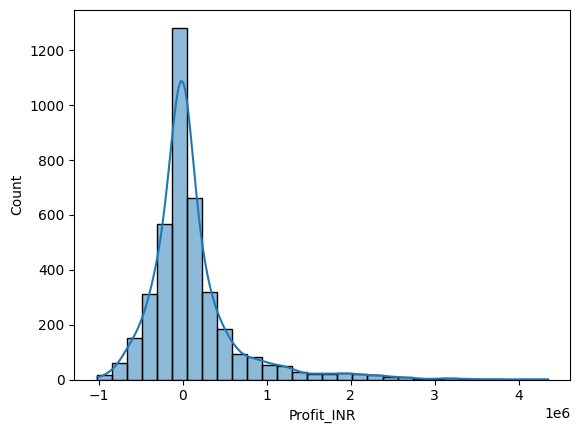

In [168]:
# Profit Distribution

sns.histplot(data['Profit_INR'],bins=30,kde=True)
plt.show()

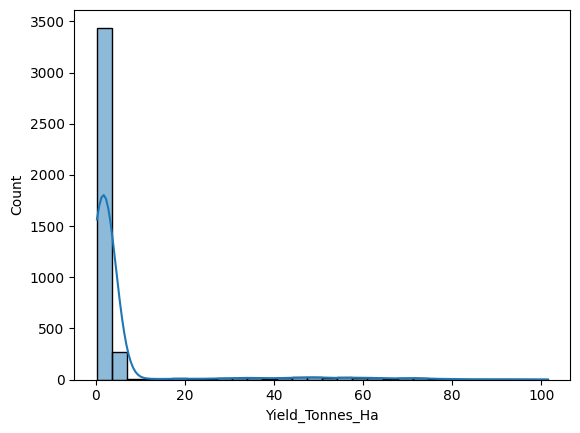

In [169]:
# Yield Distribution

sns.histplot(data['Yield_Tonnes_Ha'],bins=30,kde=True)
plt.show()

### **ANOVA Interpretation**

If p-value < 0.05:
Season has a statistically significant impact on agricultural profit.

If p-value > 0.05:
No statistically significant seasonal difference was observed.

## **Key Questions**

1. How does agricultural performance vary across seasons?
2. Which season generates highest profit?
3. Which season has highest yield?
4. How does resource usage vary?
5. How do environmental factors affect outcomes?
6. Are seasonal patterns consistent across states?
7. Which crops perform best in different seasons?
8. Are there unusual agricultural patterns?

1. Kharif recorded highest average rainfall.
2. Rabi achieved highest average yield.
3. Profitability varied across seasons.
4. Resource consumption differed significantly.
5. Water usage showed positive relationship with yield.
6. Certain states consistently outperformed others.
7. Disease risk varied seasonally.

# Recommendations Section

1. Promote high-performing crops during profitable seasons.
2. Improve irrigation planning in low-rainfall periods.
3. Monitor disease-prone seasons closely.
4. Optimize fertilizer and pesticide use.
5. Develop region-specific farming strategies.

## **Insights & Recommendations**

### **Key Insights:**
1. **Seasonal Variation:** Performance and yields vary significantly across Kharif, Rabi, and Zaid seasons due to variations in rainfall and sunlight hours.
2. **Crop Yield & Financial Risk:** High input costs during specific seasons lower net profitability despite high production output.
3. **Resource Efficiency:** Micro-irrigation methods demonstrate superior water efficiency compared to traditional flood irrigation.

### **Actionable Recommendations:**
* **Optimize Crop Selection:** Align crop choices strictly with seasonal water availability and soil moisture thresholds to minimize yield losses.
* **Cost Control:** Implement precision farming practices for fertilizer and pesticide application to control high production costs.
* **Water & Risk Management:** Adopt efficient irrigation techniques and monitor disease risk metrics preemptively during high-humidity periods.


# **Conclusion Section**

The analysis revealed significant seasonal differences in environmental conditions, resource usage, crop production, and economic outcomes.

Seasonal patterns identified in this study can support better agricultural planning, resource allocation, and decision-making.

The findings demonstrate the value of data analytics in understanding agricultural performance and improving farming strategies.